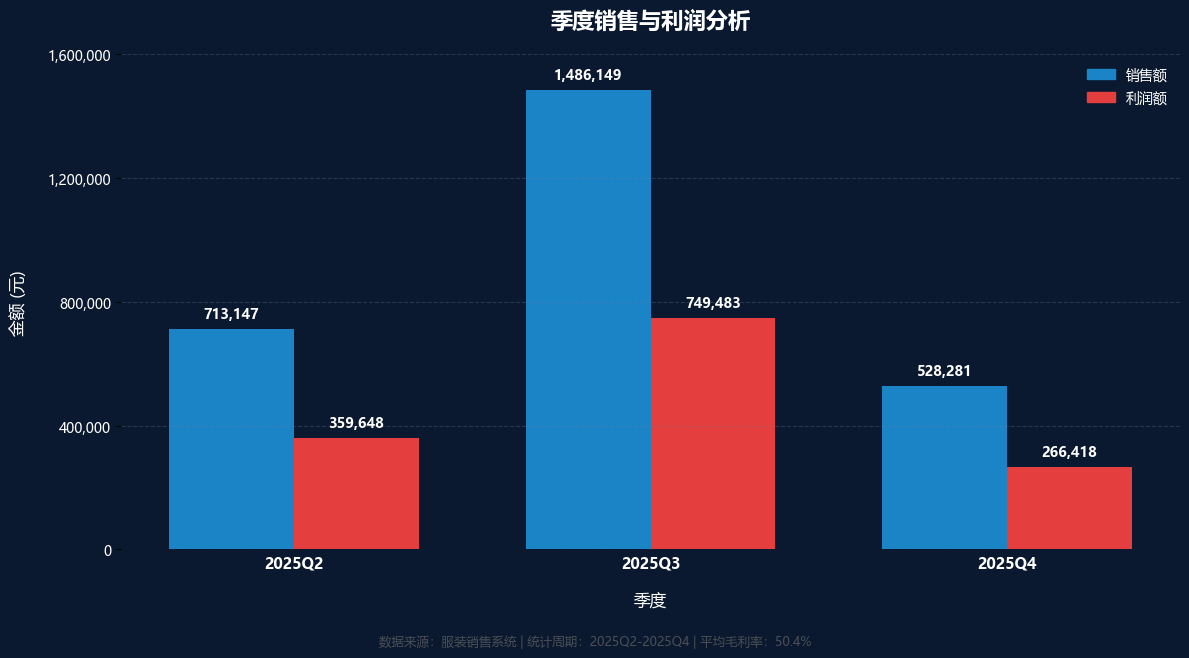

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

# 读取生成的数据集
try:
    # 严格读取CSV文件
    orders = pd.read_csv('../../erp_order.csv', encoding='utf-8-sig')
    spu_data = pd.read_csv('../../spu_manages_feishu.csv', encoding='utf-8-sig')
    
    # 检查必要的列是否存在
    required_columns_orders = ['下单时间', '商品金额']
    required_columns_spu = ['销售金额', '销售毛利']
    
    for col in required_columns_orders:
        if col not in orders.columns:
            raise ValueError(f"订单数据中缺少必要列: {col}")
    
    for col in required_columns_spu:
        if col not in spu_data.columns:
            raise ValueError(f"SPU数据中缺少必要列: {col}")
    
    # 转换日期列
    orders['下单时间'] = pd.to_datetime(orders['下单时间'], errors='coerce')
    
    # 过滤无效日期
    orders = orders[orders['下单时间'].notnull()]
    
    # 计算平均毛利率
    valid_spu = spu_data[(spu_data['销售金额'] > 0) & (spu_data['销售毛利'] > 0)]
    if not valid_spu.empty:
        avg_gross_margin = (valid_spu['销售毛利'] / valid_spu['销售金额']).mean()
    else:
        raise ValueError("无法计算平均毛利率：SPU数据中没有有效的销售金额和销售毛利")
    
    # 按季度分组
    orders['季度'] = orders['下单时间'].dt.to_period('Q').astype(str)
    
    # 获取最新的6个季度
    all_quarters = orders['季度'].unique()
    if len(all_quarters) > 6:
        # 取最近的6个季度
        all_quarters = sorted(all_quarters)[-6:]
    else:
        all_quarters = sorted(all_quarters)
    
    if not all_quarters:
        raise ValueError("没有可分析的季度数据")
    
    # 仅保留最近6个季度的数据
    orders = orders[orders['季度'].isin(all_quarters)]
    
    if orders.empty:
        raise ValueError("没有符合条件的订单数据")
    
    # 按季度汇总销售额
    quarterly_sales = orders.groupby('季度')['商品金额'].sum().reset_index()
    
    # 确保季度顺序
    quarterly_sales['季度'] = pd.Categorical(quarterly_sales['季度'], 
                                          categories=all_quarters, 
                                          ordered=True)
    quarterly_sales = quarterly_sales.sort_values('季度')
    
    # 计算利润（销售额 * 平均毛利率）
    quarterly_sales['利润额'] = quarterly_sales['商品金额'] * avg_gross_margin
    
    # 准备数据 - 显式转换为列表
    x = list(range(len(quarterly_sales)))
    sales = quarterly_sales['商品金额'].values.tolist()
    profit = quarterly_sales['利润额'].values.tolist()
    
    # 创建深色背景的图表
    fig, ax = plt.subplots(figsize=(12, 7), dpi=100)
    fig.patch.set_facecolor('#0a192f')  # 深蓝色背景
    ax.set_facecolor('#0a192f')
    
    # 设置柱子宽度
    width = 0.35  # 柱子宽度
    
    # 绘制销售额柱状图（蓝色）
    bars1 = ax.bar(
        [i - width/2 for i in x],  # 左侧位置
        sales, 
        width=width,
        color='#1a84c7',  # 蓝色
        edgecolor='none',
        label='销售额'
    )
    
    # 绘制利润额柱状图（红色）
    bars2 = ax.bar(
        [i + width/2 for i in x],  # 右侧位置
        profit, 
        width=width,
        color='#e53e3e',  # 红色
        edgecolor='none',
        label='利润额'
    )
    
    # ====== 设置固定间隔的Y轴刻度 ======
    # 计算Y轴上限（向上取整到400,000的倍数）
    max_val = max(max(sales), max(profit))
    # 计算刻度上限（400,000的整数倍）
    y_top = ((max_val // 400000) + 1) * 400000
    # 生成固定间隔的刻度
    y_ticks = np.arange(0, y_top + 400000, 400000)
    
    # 设置Y轴范围和刻度
    ax.set_ylim(0, y_top)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f'{int(x):,}' for x in y_ticks], 
                      color="#ffffff", fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.3, color='#777b92')
    
    # 移除边框
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # 设置X轴标签
    ax.set_xticks(x)
    ax.set_xticklabels(quarterly_sales['季度'], color="#ffffff", fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', length=0)
    
    # 添加数据标注（销售额）
    for i, bar in enumerate(bars1):
        height = bar.get_height()
        ax.annotate(
            f"{sales[i]:,.0f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 5),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=10,
            color='white',
            fontweight='bold'
        )
    
    # 添加数据标注（利润额）
    for i, bar in enumerate(bars2):
        height = bar.get_height()
        ax.annotate(
            f"{profit[i]:,.0f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 5),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=10,
            color='white',
            fontweight='bold'
        )
    
    # 添加标题和标签
    plt.title('季度销售与利润分析', fontsize=16, fontweight='bold', color="#ffffff", pad=20)
    plt.xlabel('季度', fontsize=12, color="#ffffff", labelpad=15)
    plt.ylabel('金额 (元)', fontsize=12, color="#ffffff", labelpad=15)
    
    # 添加图例
    blue_patch = mpatches.Patch(color='#1a84c7', label='销售额')
    red_patch = mpatches.Patch(color='#e53e3e', label='利润额')
    ax.legend(handles=[blue_patch, red_patch], 
             loc='upper right',
             frameon=False,
             fontsize=10,
             labelcolor="#ffffff")
    
    # 获取第一个和最后一个季度
    first_quarter = all_quarters[0]
    last_quarter = all_quarters[-1]
    
    # 添加底部装饰
    plt.figtext(0.5, 0.02, 
               f'数据来源：服装销售系统 | 统计周期：{first_quarter}-{last_quarter} | 平均毛利率：{avg_gross_margin:.1%}', 
               ha='center', 
               fontsize=9, 
               color='#666666',
               alpha=0.7)
    
    # 修复rect参数类型问题
    plt.tight_layout(rect=(0.0, 0.05, 1.0, 0.95))
    
    # 保存高清图片
    plt.savefig('季度销售与利润分析.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    
    plt.show()
    
except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise

# 分析

- **销售额波动**：从图表中可以观察到，2025年第三季度（2025Q3）的销售额达到峰值，为1,486,149元，显著高于其他季度，这可能与季节性需求或特定的市场活动有关。

- **利润额对比**：与销售额相比，2025Q3的利润额为749,483元，虽然也是最高，但与销售额的增长不成比例，这可能表明该季度的成本较高或折扣力度较大。

- **季度下降趋势**：2025年第二季度（2025Q2）和第四季度（2025Q4）的销售额分别为713,147元和528,281元，显示出从第三季度到第四季度销售额有显著下降，这可能与市场需求的季节性变化有关。

- **利润额的季度变化**：2025Q2的利润额为359,648元，而2025Q4的利润额进一步下降至266,418元，这可能反映了在销售额下降的同时，成本控制或利润率也面临挑战。


# 结论

该图表提供了对不同季度销售额与利润额的直观比较，揭示了销售额和利润额之间的动态关系。2025Q3的销售额和利润额的高峰可能与特定的市场策略或季节性因素有关，而随后的下降则提示了市场可能存在的不确定性或竞争压力。为了更深入地理解这些趋势，建议进行进一步的市场分析，包括成本结构、市场活动效果以及消费者行为的研究，以便为未来的销售和利润优化提供数据支持。此外，考虑到平均毛利率为50.4%，企业可能需要评估其定价策略和成本管理，以确保在不同市场条件下保持健康的盈利能力。